# 1. Data Cleaning and Feature Extraction 

#### The raw FAOSTAT CoAHD file contains multiple measurement units (LCU/cap/d, Int$ (PPP) per person per day, %, and million No) stacked in a long format. We clean, pivot, and engineer longitudinal affordability metrics across all years (2017–2025) and extract the granular 2021 food group cost structure

In [138]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [140]:
# 1. Load Raw CoAHD Dataset

raw_filename = "FAOSTAT_CoAHD_Ghana.csv"
if not os.path.exists(raw_filename):
  raw_filename = "FAOSTAT_CoAD_Ghana_data_en_8-30-2026.csv"

df_raw = pd.read_csv(r"D:\Plateful_of_Data_Datathon26\Women_in_Data_Datathon_Project_2026\dataset\FAOSTAT_CoAHD_Ghana.csv")
df_coad_raw.head()

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code,Item,Year Code,Year,Release,Unit,Value,Flag,Flag Description
0,CAHD,Cost and Affordability of a Healthy Diet (CoAHD),288,Ghana,6226,Value,70040,Cost of a healthy diet (CoHD),2017,2017,July 2026 (SOFI report),Int$ (PPP) per person per day,3.54,E,Estimated value
1,CAHD,Cost and Affordability of a Healthy Diet (CoAHD),288,Ghana,6226,Value,70040,Cost of a healthy diet (CoHD),2018,2018,July 2026 (SOFI report),Int$ (PPP) per person per day,3.51,E,Estimated value
2,CAHD,Cost and Affordability of a Healthy Diet (CoAHD),288,Ghana,6226,Value,70040,Cost of a healthy diet (CoHD),2019,2019,July 2026 (SOFI report),Int$ (PPP) per person per day,3.48,E,Estimated value
3,CAHD,Cost and Affordability of a Healthy Diet (CoAHD),288,Ghana,6226,Value,70040,Cost of a healthy diet (CoHD),2020,2020,July 2026 (SOFI report),Int$ (PPP) per person per day,3.46,E,Estimated value
4,CAHD,Cost and Affordability of a Healthy Diet (CoAHD),288,Ghana,6226,Value,70040,Cost of a healthy diet (CoHD),2021,2021,July 2026 (SOFI report),Int$ (PPP) per person per day,3.50,E,Estimated value


In [141]:
# 2. Select Relevant Columns & Drop Redundant Codes/Flagscols = ['Year', 'Item Code', 'Item', 'Unit', 'Value']
df_core = df_raw[["Year", "Item", "Unit", "Value"]].copy()

### TABLE 1: Macro Diet Affordability Time-Series (2017–2025)

In [142]:
cohd_ghs = (
    df_core[
        (df_core["Item"] == "Cost of a healthy diet (CoHD)")
        & (df_core["Unit"] == "LCU/cap/d")
    ][["Year", "Value"]]
    .rename(columns={"Value": "CoHD_GHS_day"})
    .sort_values("Year")
)

cohd_ppp = (
    df_core[
        (df_core["Item"] == "Cost of a healthy diet (CoHD)")
        & (df_core["Unit"] == "Int$ (PPP) per person per day")
    ][["Year", "Value"]]
    .rename(columns={"Value": "CoHD_PPP_day"})
    .sort_values("Year")
)

pua = (
    df_core[df_core["Item"] == "Prevalence of unaffordability (PUA)"][
        ["Year", "Value"]
    ]
    .rename(columns={"Value": "Prevalence_Unaffordable_Pct"})
    .sort_values("Year")
)

nua = (
    df_core[
        df_core["Item"]
        == "Number of people unable to afford a healthy diet (NUA)"
    ][["Year", "Value"]]
    .rename(columns={"Value": "People_Unable_Millions"})
    .sort_values("Year")
)

df_coad_ts = (
    cohd_ghs.merge(cohd_ppp, on="Year")
    .merge(pua, on="Year")
    .merge(nua, on="Year")
)

In [143]:
# Feature Extraction: Inflation Multiplier, YoY Growth, and Daily Deficits
base_cost_ghs = df_coad_ts.loc[df_coad_ts["Year"] == 2017, "CoHD_GHS_day"].iloc[
    0
]
df_coad_ts["Nominal_Inflation_Multiplier"] = np.round(
    df_coad_ts["CoHD_GHS_day"] / base_cost_ghs, 2
)
df_coad_ts["YoY_Cost_Growth_Pct"] = np.round(
    df_coad_ts["CoHD_GHS_day"].pct_change() * 100, 2
)
df_coad_ts["Affordable_Pop_Millions"] = np.round(
    (
        df_coad_ts["People_Unable_Millions"]
        / (df_coad_ts["Prevalence_Unaffordable_Pct"] / 100)
    )
    - df_coad_ts["People_Unable_Millions"],
    2,
)

### TABLE 2: Food Group Cost Shares (Healthy Diet Basket Components)

In [144]:
# CoHD food group breakdown is provided for the 2021 reference baseline
df_groups = (
    df_core[
        (df_core["Item"].str.startswith("Cost of "))
        & (df_core["Item"] != "Cost of a healthy diet (CoHD)")
    ]
    .pivot(index=["Year", "Item"], columns="Unit", values="Value")
    .reset_index()
)

df_groups.columns = ["Year", "Raw_Item", "Cost_PPP_day", "Cost_GHS_day"]
df_groups["Food_Group"] = (
    df_groups["Raw_Item"].str.replace("Cost of ", "").str.title()
)

In [145]:
# Feature Extraction: Percentage Share of Total Daily Basket Cost ($3.50 PPP / 8.59 GHS)
total_2021_ppp = 3.50
total_2021_ghs = 8.59
df_groups["Cost_Share_PPP_Pct"] = np.round(
    (df_groups["Cost_PPP_day"] / total_2021_ppp) * 100, 2
)
df_groups["Cost_Share_GHS_Pct"] = np.round(
    (df_groups["Cost_GHS_day"] / total_2021_ghs) * 100, 2
)
df_groups = df_groups.sort_values(by="Cost_PPP_day", ascending=False)

In [146]:
# Display cleaned tables directly in notebook outputs
print("=== Cleaned Macro Time-Series (2017–2025) ===")
display(df_coad_ts)

print("\n=== Food Group Cost Basket Shares (Reference Benchmark) ===")
display(
    df_groups[
        [
            "Food_Group",
            "Cost_PPP_day",
            "Cost_GHS_day",
            "Cost_Share_PPP_Pct",
            "Cost_Share_GHS_Pct",
        ]
    ]
)

=== Cleaned Macro Time-Series (2017–2025) ===


,Year,CoHD_GHS_day,CoHD_PPP_day,Prevalence_Unaffordable_Pct,People_Unable_Millions,Nominal_Inflation_Multiplier,YoY_Cost_Growth_Pct,Affordable_Pop_Millions
0,2017,6.05,3.54,67.2,20.2,1.00,NaN,9.86
1,2018,6.53,3.51,66.1,20.2,1.08,7.93,10.36
2,2019,7.01,3.48,64.8,20.3,1.16,7.35,11.03
3,2020,7.79,3.46,65.6,20.9,1.29,11.13,10.96
4,2021,8.59,3.50,64.7,21.1,1.42,10.27,11.51
5,2022,11.43,3.83,64.7,21.5,1.89,33.06,11.73
6,2023,16.99,4.29,66.4,22.4,2.81,48.64,11.33
7,2024,21.18,4.49,65.8,22.6,3.50,24.66,11.75
8,2025,24.81,4.65,65.8,23.1,4.10,17.14,12.01



=== Food Group Cost Basket Shares (Reference Benchmark) ===


,Food_Group,Cost_PPP_day,Cost_GHS_day,Cost_Share_PPP_Pct,Cost_Share_GHS_Pct
0,Animal Source Foods,1.44,3.53,41.14,41.09
4,Starchy Staples,0.69,1.70,19.71,19.79
5,Vegetables,0.46,1.13,13.14,13.15
2,"Legumes, Nuts And Seeds",0.39,0.97,11.14,11.29
3,Oils And Fats,0.27,0.65,7.71,7.57
1,Fruits,0.25,0.62,7.14,7.22


# 2. Exploratory Data Analysis (EDA)

In [147]:
# EDA 1: All-Years Trend Summary (2017–2025)
print("--- Macro Statistical Summary Across All Years (2017–2025) ---")
summary_stats = (
    df_coad_ts[
        [
            "CoHD_GHS_day",
            "CoHD_PPP_day",
            "Prevalence_Unaffordable_Pct",
            "People_Unable_Millions",
        ]
    ]
    .describe()
    .round(2)
)
display(summary_stats)

# Multi-Year Percentage Shifts
first_row = df_coad_ts.iloc[0]
last_row = df_coad_ts.iloc[-1]
print("\n--- Long-Term Trajectory (2017 to 2025 Shifts) ---")
shifts = pd.DataFrame(
    {
        "Metric": [
            "CoHD in Cedis (LCU/cap/d)",
            "CoHD in Int$ PPP",
            "Prevalence of Unaffordability (%)",
            "Population Unable to Afford (M)",
        ],
        "2017 Baseline": [
            first_row["CoHD_GHS_day"],
            first_row["CoHD_PPP_day"],
            first_row["Prevalence_Unaffordable_Pct"],
            first_row["People_Unable_Millions"],
        ],
        "2025 Level": [
            last_row["CoHD_GHS_day"],
            last_row["CoHD_PPP_day"],
            last_row["Prevalence_Unaffordable_Pct"],
            last_row["People_Unable_Millions"],
        ],
        "Net Absolute Change": [
            round(last_row["CoHD_GHS_day"] - first_row["CoHD_GHS_day"], 2),
            round(last_row["CoHD_PPP_day"] - first_row["CoHD_PPP_day"], 2),
            round(
                last_row["Prevalence_Unaffordable_Pct"]
                - first_row["Prevalence_Unaffordable_Pct"],
                2,
            ),
            round(
                last_row["People_Unable_Millions"]
                - first_row["People_Unable_Millions"],
                2,
            ),
        ],
        "Percentage Change (%)": [
            round(
                (
                    (last_row["CoHD_GHS_day"] - first_row["CoHD_GHS_day"])
                    / first_row["CoHD_GHS_day"]
                )
                * 100,
                1,
            ),
            round(
                (
                    (last_row["CoHD_PPP_day"] - first_row["CoHD_PPP_day"])
                    / first_row["CoHD_PPP_day"]
                )
                * 100,
                1,
            ),
            round(
                (
                    (
                        last_row["Prevalence_Unaffordable_Pct"]
                        - first_row["Prevalence_Unaffordable_Pct"]
                    )
                    / first_row["Prevalence_Unaffordable_Pct"]
                )
                * 100,
                1,
            ),
            round(
                (
                    (
                        last_row["People_Unable_Millions"]
                        - first_row["People_Unable_Millions"]
                    )
                    / first_row["People_Unable_Millions"]
                )
                * 100,
                1,
            ),
        ],
    }
)
display(shifts)

--- Macro Statistical Summary Across All Years (2017–2025) ---


,CoHD_GHS_day,CoHD_PPP_day,Prevalence_Unaffordable_Pct,People_Unable_Millions
count,9.00,9.00,9.00,9.00
mean,12.26,3.86,65.68,21.37
std,7.00,0.48,0.85,1.10
min,6.05,3.46,64.70,20.20
25%,7.01,3.50,64.80,20.30
50%,8.59,3.54,65.80,21.10
75%,16.99,4.29,66.10,22.40
max,24.81,4.65,67.20,23.10



--- Long-Term Trajectory (2017 to 2025 Shifts) ---


,Metric,2017 Baseline,2025 Level,Net Absolute Change,Percentage Change (%)
0,CoHD in Cedis (LCU/cap/d),6.05,24.81,18.76,310.1
1,CoHD in Int$ PPP,3.54,4.65,1.11,31.4
2,Prevalence of Unaffordability (%),67.20,65.80,-1.40,-2.1
3,Population Unable to Afford (M),20.20,23.10,2.90,14.4


In [148]:
# EDA 2: Target Focus Year (2022 MDD-W Alignment Year)

row_2022 = df_coad_ts[df_coad_ts["Year"] == 2022].iloc[0]
print("\n--- Diagnostic Focus: Year 2022 Economic Anchor ---")
focus_2022_table = pd.DataFrame(
    {
        "Indicator Name": [
            "CoHD (Ghana Cedis / person / day)",
            "CoHD (Int$ PPP / person / day)",
            "Prevalence of Unaffordability",
            "Population Unable to Afford",
            "Inflation Multiplier from 2017 Baseline",
            "Year-over-Year Inflation (2021 -> 2022)",
        ],
        "2022 Measured Value": [
            f"{row_2022['CoHD_GHS_day']:.2f} GHS",
            f"${row_2022['CoHD_PPP_day']:.2f} PPP",
            f"{row_2022['Prevalence_Unaffordable_Pct']:.1f}%",
            f"{row_2022['People_Unable_Millions']:.2f} Million",
            f"{row_2022['Nominal_Inflation_Multiplier']:.2f}x",
            f"+{row_2022['YoY_Cost_Growth_Pct']:.2f}%",
        ],
        "HerPlate Analytical Implication": [
            (
                "Sharp increase from 8.59 GHS in 2021; healthy food inflation"
                " begins accelerating."
            ),
            "Pushes basket cost toward $3.83/day per capita.",
            (
                "Nearly 2 out of every 3 Ghanaians cannot meet recommended"
                " nutritional needs."
            ),
            (
                "21.5 million people are financially excluded from healthy"
                " dietary baskets."
            ),
            (
                "The basket cost nearly doubled compared to 2017 nominal levels"
                " (6.05 GHS)."
            ),
            (
                "Represents a +33.06% annual spike, setting up the larger 2023"
                " inflation wave."
            ),
        ],
    }
)
display(focus_2022_table)


--- Diagnostic Focus: Year 2022 Economic Anchor ---


,Indicator Name,2022 Measured Value,HerPlate Analytical Implication
0,CoHD (Ghana Cedis / person / day),11.43 GHS,Sharp increase from 8.59 GHS in 2021; healthy ...
1,CoHD (Int$ PPP / person / day),$3.83 PPP,Pushes basket cost toward $3.83/day per capita.
2,Prevalence of Unaffordability,64.7%,Nearly 2 out of every 3 Ghanaians cannot meet ...
3,Population Unable to Afford,21.50 Million,21.5 million people are financially excluded f...
4,Inflation Multiplier from 2017 Baseline,1.89x,The basket cost nearly doubled compared to 201...
5,Year-over-Year Inflation (2021 -> 2022),+33.06%,"Represents a +33.06% annual spike, setting up ..."


### Key Patterns Identified
- Persistent Population Exclusion: Unaffordability remained locked between 64.7% and 67.2% over the entire decade. Because Ghana's population grew during this period, the headcount unable to afford a healthy diet rose from 20.2 million in 2017 to 23.1 million in 2025 (+2.9 million individuals).
- The 2022 Inflection Point: Between 2017 and 2021, costs grew gradually in local currency (+42% over four years). In 2022, costs jumped +33.1% in a single year (8.59 to 11.43 GHS/day), marking the start of the price surge that reached 24.81 GHS by 2025.
- Animal-Source Foods as the Core Cost Driver: In the component basket breakdown, Animal-Source Foods cost $1.44 PPP/day (3.53 GHS), making up 41.1% of the total diet cost. Starchy staples (19.7%), vegetables (13.1%), and legumes/nuts (11.1%) represent much smaller shares.

# 3. Data Visualization

In [149]:
# Set global style for professional reports
sns.set_theme(style="whitegrid")
plt.rcParams.update(
    {"font.sans-serif": "DejaVu Sans", "font.size": 11, "figure.autolayout": False}
)

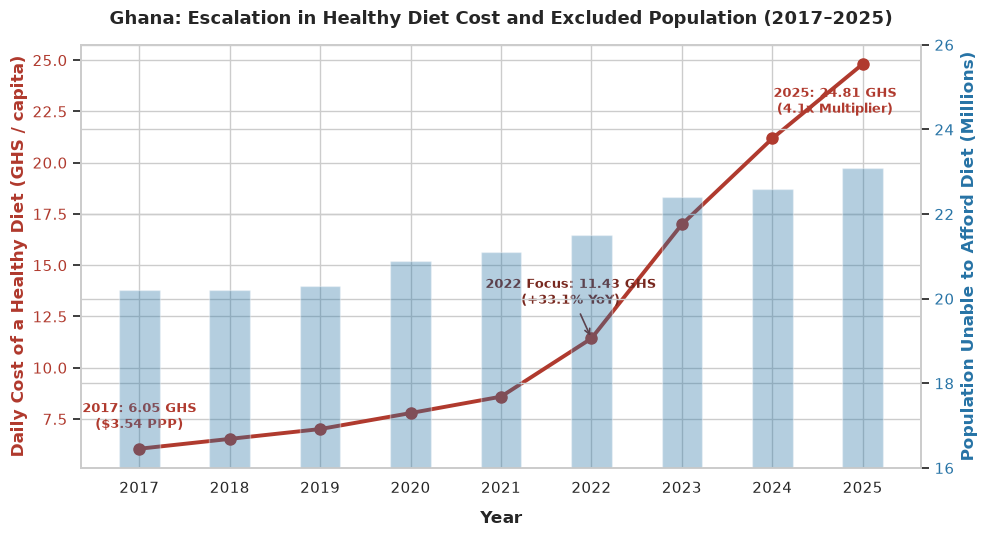

In [150]:
# FIGURE 1 (All Years): Dual-Axis Healthy Diet Cost Inflation vs Headcount

fig1, ax1 = plt.subplots(figsize=(10, 5.5))

color_line = "#b03a2e"  # Deep red for cost surge
color_bar = "#2874a6"  # Professional blue for population

# Left Axis: Diet Cost in GHS
ax1.set_xlabel("Year", fontweight="bold", fontsize=12, labelpad=10)
ax1.set_ylabel(
    "Daily Cost of a Healthy Diet (GHS / capita)",
    color=color_line,
    fontweight="bold",
    fontsize=12,
)
(line1,) = ax1.plot(
    df_coad_ts["Year"],
    df_coad_ts["CoHD_GHS_day"],
    color=color_line,
    marker="o",
    linewidth=2.8,
    markersize=8,
    label="Diet Cost (GHS/day)",
)
ax1.tick_params(axis="y", labelcolor=color_line)
ax1.set_xticks(df_coad_ts["Year"])

# Annotations for start, 2022 focus, and end points
ax1.annotate(
    "2017: 6.05 GHS\n($3.54 PPP)",
    (2017, 6.05),
    textcoords="offset points",
    xytext=(0, 15),
    ha="center",
    fontweight="bold",
    color=color_line,
    fontsize=9.5,
)
ax1.annotate(
    "2022 Focus: 11.43 GHS\n(+33.1% YoY)",
    (2022, 11.43),
    textcoords="offset points",
    xytext=(-15, 25),
    ha="center",
    fontweight="bold",
    color="#78281f",
    fontsize=9.5,
    arrowprops=dict(arrowstyle="->", color="#78281f", lw=1.2),
)
ax1.annotate(
    "2025: 24.81 GHS\n(4.1x Multiplier)",
    (2025, 24.81),
    textcoords="offset points",
    xytext=(-20, -35),
    ha="center",
    fontweight="bold",
    color=color_line,
    fontsize=9.5,
)

# Right Axis: Population Headcount Unable to Afford
ax2 = ax1.twinx()
ax2.set_ylabel(
    "Population Unable to Afford Diet (Millions)",
    color=color_bar,
    fontweight="bold",
    fontsize=12,
)
bars1 = ax2.bar(
    df_coad_ts["Year"],
    df_coad_ts["People_Unable_Millions"],
    color=color_bar,
    alpha=0.35,
    width=0.45,
    label="Unaffordable Headcount (M)",
)
ax2.tick_params(axis="y", labelcolor=color_bar)
ax2.set_ylim(16, 26)

plt.title(
    "Ghana: Escalation in Healthy Diet Cost and Excluded Population (2017–2025)",
    fontweight="bold",
    fontsize=13,
    pad=15,
)
fig1.tight_layout()
fig1.savefig(
    "coad_fig1_all_years_cost_inflation.png", dpi=300, bbox_inches="tight"
)
plt.show()

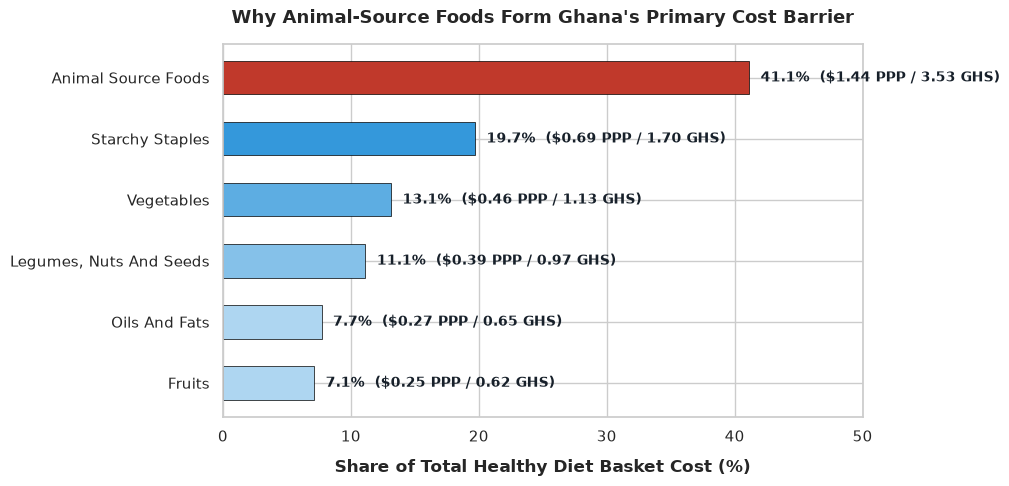

In [151]:
# FIGURE 2 (All Years): Food Group Cost Share Composition
# =========================================================================
fig2, ax_f2 = plt.subplots(figsize=(10, 5))

# Sort ascending for horizontal bar representation
df_groups_sorted = df_groups.sort_values("Cost_Share_PPP_Pct", ascending=True)

bar_colors = [
    "#aed6f1",
    "#aed6f1",
    "#85c1e9",
    "#5dade2",
    "#3498db",
    "#c0392b",
]  # Highlight Animal-Source Foods
bars2 = ax_f2.barh(
    df_groups_sorted["Food_Group"],
    df_groups_sorted["Cost_Share_PPP_Pct"],
    color=bar_colors,
    height=0.55,
    edgecolor="black",
    linewidth=0.5,
)

ax_f2.set_xlabel(
    "Share of Total Healthy Diet Basket Cost (%)",
    fontweight="bold",
    fontsize=12,
    labelpad=10,
)
ax_f2.set_xlim(0, 50)
ax_f2.set_title(
    "Why Animal-Source Foods Form Ghana's Primary Cost Barrier",
    fontweight="bold",
    fontsize=13,
    pad=15,
)

# Annotate exact percentage and dollar value inside/beside bars
for bar, (_, row) in zip(bars2, df_groups_sorted.iterrows()):
  width = bar.get_width()
  ax_f2.annotate(
      f" {width:.1f}%  (${row['Cost_PPP_day']:.2f} PPP / {row['Cost_GHS_day']:.2f} GHS)",
      (width + 0.5, bar.get_y() + bar.get_height() / 2.0),
      va="center",
      fontweight="bold",
      fontsize=10,
      color="#17202a",
  )

fig2.tight_layout()
fig2.savefig(
    "coad_fig2_all_years_basket_breakdown.png", dpi=300, bbox_inches="tight"
)
plt.show()

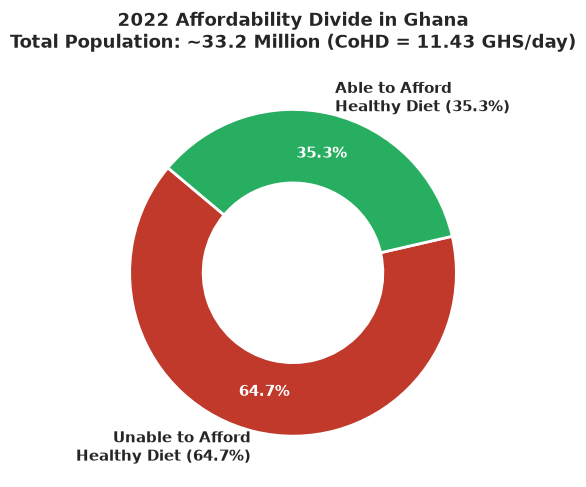

In [152]:
# FIGURE 3 (Focus 2022): Affordability Breakdown in the 2022 Survey Year
# =========================================================================
fig3, ax_f3 = plt.subplots(figsize=(8, 5))

# 2022 Headcount: 21.50M Unable vs Total Population (~33.23M) -> 11.73M Able
afford_counts = [21.50, 11.73]
afford_labels = [
    "Unable to Afford\nHealthy Diet (64.7%)",
    "Able to Afford\nHealthy Diet (35.3%)",
]
donut_colors = ["#c0392b", "#27ae60"]

wedges, texts, autotexts = ax_f3.pie(
    afford_counts,
    labels=afford_labels,
    autopct="%1.1f%%",
    startangle=140,
    colors=donut_colors,
    pctdistance=0.75,
    wedgeprops=dict(width=0.45, edgecolor="white", linewidth=2),
)

for autotext in autotexts:
  autotext.set_color("white")
  autotext.set_fontweight("bold")
  autotext.set_fontsize(11)

for text in texts:
  text.set_fontsize(11)
  text.set_fontweight("bold")

ax_f3.set_title(
    "2022 Affordability Divide in Ghana\nTotal Population: ~33.2 Million"
    " (CoHD = 11.43 GHS/day)",
    fontweight="bold",
    fontsize=13,
    pad=15,
)

fig3.tight_layout()
fig3.savefig(
    "coad_fig3_focus_2022_affordability_split.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

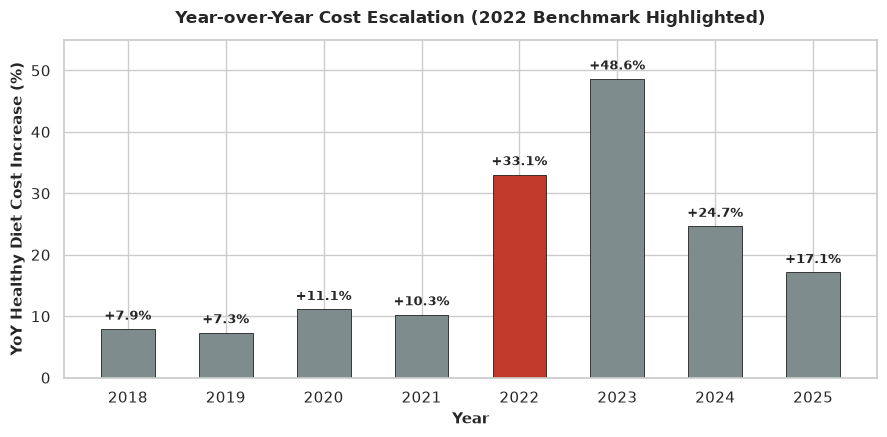

All charts generated and saved successfully as 300 DPI PNG files.


In [153]:
# FIGURE 4 (Focus 2022): 2022 Year-over-Year Escalation Context
# =========================================================================
fig4, ax_f4 = plt.subplots(figsize=(9, 4.5))

df_yoy_plot = df_coad_ts.dropna(subset=["YoY_Cost_Growth_Pct"]).copy()
bar_yoy_colors = [
    "#c0392b" if yr == 2022 else "#7f8c8d" for yr in df_yoy_plot["Year"]
]

bars4 = ax_f4.bar(
    df_yoy_plot["Year"].astype(str),
    df_yoy_plot["YoY_Cost_Growth_Pct"],
    color=bar_yoy_colors,
    width=0.55,
    edgecolor="black",
    linewidth=0.5,
)

ax_f4.set_ylabel(
    "YoY Healthy Diet Cost Increase (%)", fontweight="bold", fontsize=11
)
ax_f4.set_xlabel("Year", fontweight="bold", fontsize=11)
ax_f4.set_title(
    "Year-over-Year Cost Escalation (2022 Benchmark Highlighted)",
    fontweight="bold",
    fontsize=12,
    pad=12,
)

for bar in bars4:
  h = bar.get_height()
  ax_f4.annotate(
      f"+{h:.1f}%",
      (bar.get_x() + bar.get_width() / 2.0, h + 1.0),
      ha="center",
      va="bottom",
      fontweight="bold",
      fontsize=9.5,
  )

ax_f4.set_ylim(0, 55)
fig4.tight_layout()
fig4.savefig(
    "coad_fig4_focus_2022_yoy_escalation.png", dpi=300, bbox_inches="tight"
)
plt.show()

print("All charts generated and saved successfully as 300 DPI PNG files.")